# Backpropagation XOR

In [23]:
import numpy as np

In [24]:
X = np.array([
                [0,0],
                [0,1],
                [1,0],
                [1,1]
])

Y = np.array([[0],[1],[1],[0]])

In [25]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

def sigmoid_derivative(x):
    return sigmoid(x) * (1 - sigmoid(x))

In [26]:
def cost_function(y_true, y_pred):
    return np.mean(np.square(y_true - y_pred))

In [27]:
hidden_layer_neurons = 2
output_layer_neurons = 1

W1 = np.random.uniform(size=(X.shape[1], hidden_layer_neurons))
B1 = np.random.uniform(size=(1, hidden_layer_neurons))
W2 = np.random.uniform(size=(hidden_layer_neurons, output_layer_neurons))
B2 = np.random.uniform(size=(1, output_layer_neurons))


In [28]:
learning_rate = 0.1
epochs = 400
costs = []
for epoch in range(epochs):
    # Forward Propagation
    Z1 = np.dot(X, W1) + B1
    A1 = sigmoid(Z1)
    Z2 = np.dot(A1, W2) + B2
    A2 = sigmoid(Z2)
    # Calculate Cost
    cost = cost_function(Y, A2)
    costs.append(cost)
    # Backward Propagation
    m = X.shape[0]
    dZ2 = (A2 - Y) * sigmoid_derivative(Z2)
    dZ1 = np.dot(dZ2, W2.T) * sigmoid_derivative(Z1)
    DW2 = np.dot(A1.T, dZ2) / m
    DB2 = np.sum(dZ2, axis=0, keepdims=True) / m
    DW1 = np.dot(X.T, dZ1) / m
    DB1 = np.sum(dZ1, axis=0, keepdims=True) / m
    # Update Weights and Biases
    W2 -= learning_rate * DW2
    B2 -= learning_rate * DB2
    W1 -= learning_rate * DW1
    B1 -= learning_rate * DB1

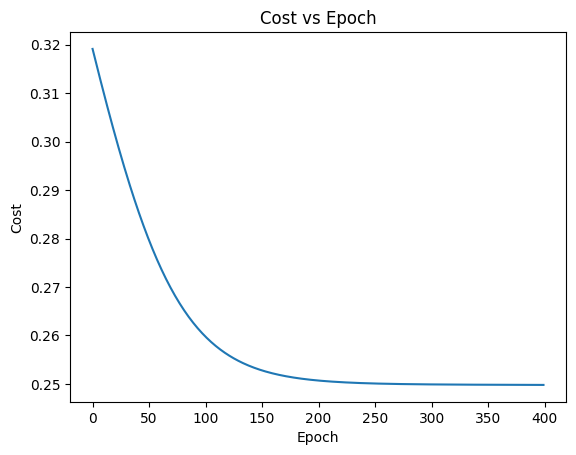

In [29]:
import matplotlib.pyplot as plt

plt.plot(costs)
plt.title("Cost vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.show()